In [19]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# because i need to import this nlng rather than pyfim huhuhu 
try:
    import pyfpgrowth
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyfpgrowth"])
    import pyfpgrowth

from sklearn.preprocessing import MultiLabelBinarizer
from collections import defaultdict

In [20]:
#folder_path = "/mnt/data/public/food-com-recipes/RAW_recipes.csv"
folder_path = "data/RAW_recipes.csv"
df = pd.read_csv(folder_path)

# Convert the tags into a list
df["nutrition"] = df["nutrition"].apply(json.loads)
# Convert the tags into 
df['tags'] = df['tags'].apply(
    lambda x: [item.strip("'\"") for item in x.strip("[]").split(", ")]
)
df['ingredients'] = df['ingredients'].apply(
    lambda x: [item.strip("'\"") for item in x.strip("[]").split(", ")]
)

# Find the frequent itemsets of all recipes

In [4]:
num_recipes = len(df['ingredients'])
min_support_pct = 0.02
minsup_count = max(1, int(num_recipes * min_support_pct))

all_freq_ingredients = pyfpgrowth.find_frequent_patterns(df['ingredients'].to_list(), minsup_count)

In [5]:
# Create a dictionary to store counts by itemset length
all_freq_counts = defaultdict(int)

for itemset in all_freq_ingredients.keys():
    k = len(itemset)  # length of the itemset
    all_freq_counts[k] += 1

# Convert to regular dict and optionally sort by k
all_freq_counts = dict(sorted(all_freq_counts.items()))
print(all_freq_counts)

all_three_itemsets = {k: v for k, v in all_freq_ingredients.items() if len(k) == 3}

{1: 54, 2: 72, 3: 32}


## Get Healthy Recipes

We classified a recipe to be healthy if it has the tags 'healthy' or 'healthy-2'. I am adding here the nutritional values in case that it will become importantly.

In [6]:
# Get the nutritional values
nutrition_cols = [
    "calories",
    "total_fat_PDV",
    "sugar_PDV",
    "sodium_PDV",
    "protein_PDV",
    "saturated_fat_PDV",
    "carbohydrates_PDV",
]

df_all_nutritions = df["nutrition"].apply(pd.Series)
df_all_nutritions.columns = nutrition_cols

Let us check on the distributions of the nutrtional values.

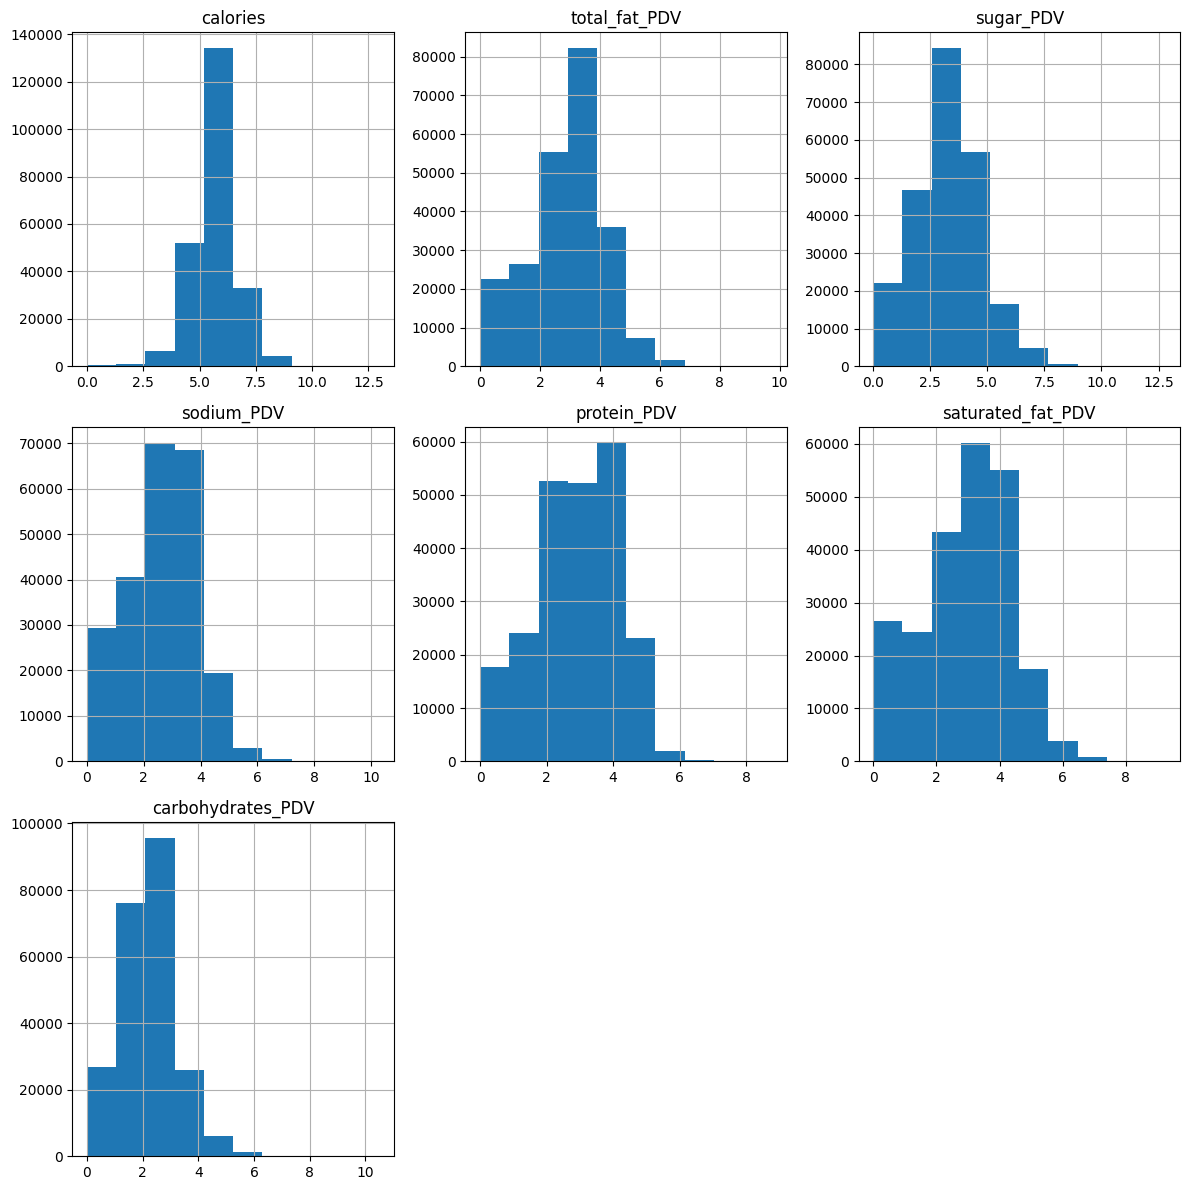

In [7]:
np.log1p(df_all_nutritions).hist(figsize=(12, 12))
plt.tight_layout()

In [18]:
# Create a tags presence matrix
mlb = MultiLabelBinarizer()
tags_matrix = mlb.fit_transform(df['tags'])
df_tags_matrix = pd.DataFrame(tags_matrix, columns=mlb.classes_, index=df.index)

# Get the healthy foods based on the tags
is_healthy_tag = df_tags_matrix['healthy'] == 1
is_healthy_2_tag = df_tags_matrix['healthy-2'] == 1
is_health_tag = is_healthy_tag | is_healthy_2_tag
is_healthy_food = df_tags_matrix[is_health_tag].index

df_healthy = df.loc[is_healthy_food]

# Save the csv
pd.Series(is_healthy_food).to_csv('data/is_healthy_food.csv', index=False, header=False)

In [9]:
df_healthy.to_json('data/healthy_foods.json', orient='records')

# Filtering for Healthy Recipes, we check for the frequent ingredients

In [10]:
# filtering for Healthy Foods, we check for the frequent ingredients
num_recipes = len(df_healthy['ingredients'])
min_support_pct = 0.02
minsup_count = max(1, int(num_recipes * min_support_pct))

healthy_freq_ingredients = pyfpgrowth.find_frequent_patterns(df_healthy['ingredients'].to_list(), minsup_count)

In [11]:
# Create a dictionary to store counts by itemset length
healthy_freq_counts = defaultdict(int)

for itemset in healthy_freq_ingredients.keys():
    k = len(itemset)  # length of the itemset
    healthy_freq_counts[k] += 1

# Convert to regular dict and optionally sort by k
freq_counts = dict(sorted(healthy_freq_counts.items()))

# Get the healthy itemsets
healthy_three_itemsets = {k: v for k, v in healthy_freq_ingredients.items() if len(k) == 3}


# Compare if the frequent ingredients in all and healthy-only recipes are similar

We use the Jaccard index as a way to measure similarity. Since the similarity is 0.52 between the frequent ingredient itemsets of all recipes and healthy-only recipes, this indicates that there is only a moderate overlap between the two groups. In other words, nearly half of the commonly used ingredients in healthy recipes are not the same as those in the general recipe population. This suggests that healthy recipes rely on a distinct set of ingredients, reflecting meaningful differences in ingredient composition and dietary choices.

In [25]:
all_freq_ingredients.keys()

dict_keys([('orange juice',), ('dried oregano',), ('mozzarella cheese',), ('margarine',), ('heavy cream',), ('fresh lemon juice',), ('powdered sugar',), ('kosher salt',), ('green onion',), ('dijon mustard',), ('pecans',), ('walnuts',), ('red onion',), ('green onions',), ('ground beef',), ('ground cumin',), ('granulated sugar',), ('cayenne pepper',), ('nutmeg',), ('potatoes',), ('lemon',), ('carrot',), ('ground cinnamon',), ('bacon',), ('chili powder',), ('parsley',), ('carrots',), ('fresh ground black pepper',), ('cornstarch',), ('fresh parsley',), ('extra virgin olive oil',), ('worcestershire sauce',), ('chicken broth',), ('paprika',), ('mayonnaise',), ('soy sauce',), ('unsalted butter',), ('cheddar cheese',), ('celery',), ('celery', 'onion'), ('garlic clove',), ('cream cheese',), ('onions',), ('onions', 'salt'), ('honey',), ('oil',), ('oil', 'salt'), ('sugar', 'vanilla extract'), ('salt', 'vanilla extract'), ('garlic powder',), ('garlic powder', 'salt'), ('sour cream',), ('tomatoes',

In [12]:
def jaccard_index(list1, list2):
    set1 = set(list1)
    set2 = set(list2)

    if not set1 and not set2:
        return 0  # avoid division by zero when both lists are empty

    intersection = len(set1 & set2)  # common elements
    union = len(set1 | set2)         # total unique elements
    return intersection / union

jaccard_index(list(all_freq_ingredients.keys()), list(healthy_freq_ingredients.keys()))

0.5284974093264249

We also check the differences in the distribution of the nutritional values between all the recipes and just the healthy recipes. We see that most of them are similar, except for total_fat_PDV and saturated_fat_PDV. THis makes sense because like...yeahh....

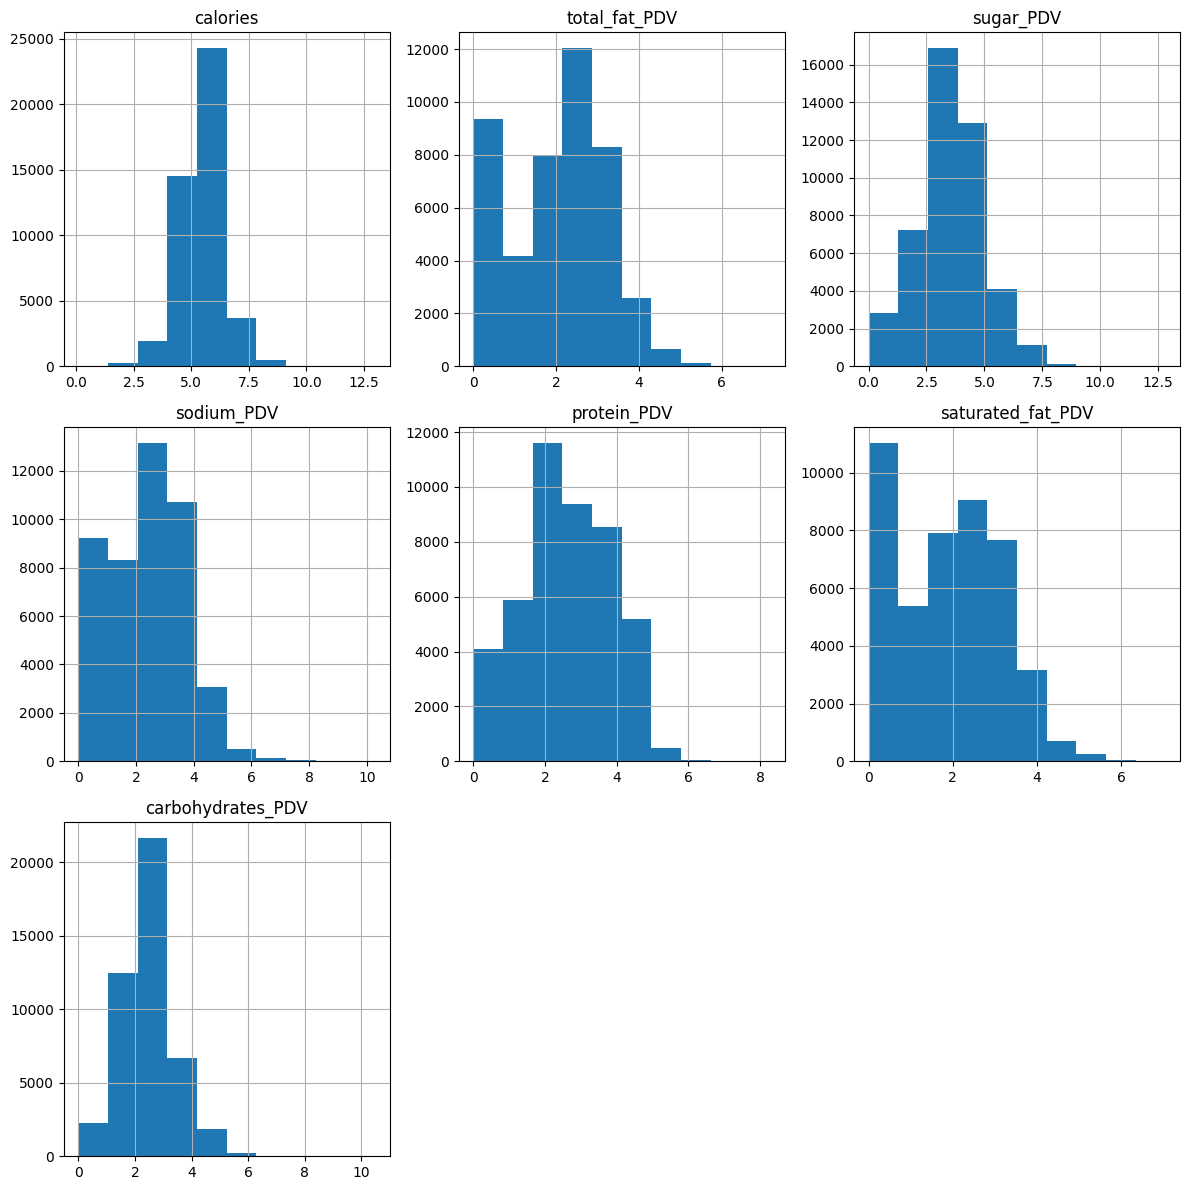

In [13]:
df_healthy_nutritions = df_healthy['nutrition'].apply(pd.Series)
df_healthy_nutritions.columns = nutrition_cols
np.log1p(df_healthy_nutritions).hist(figsize=(12, 12))
plt.tight_layout()

# We now check on the rules

Based on the association rules, salt and sugar appear as consequents in many high-confidence itemsets, such as pairs involving flour, baking powder, and eggs. This shows that these ingredients are central to most recipes and frequently co-occur with common bases for baked goods. Focusing on reducing salt and sugar would therefore have the greatest impact on making recipes healthier while retaining their core structure. Thus, we suggest using natural sweeteners such as dates, honey, or applesauce instead of sugar, and herbs, spices, or potassium-based salts instead of regular salt. These substitutions help maintain flavor and texture while improving the nutritional profile of the recipes.

In [14]:
healthy_rules = pyfpgrowth.generate_association_rules(healthy_freq_ingredients, 0.7)


In [26]:
healthy_rules

{('baking soda', 'sugar'): (('salt',), 0.7771381578947368),
 ('baking powder', 'baking soda'): (('salt',), 0.7635542168674698),
 ('all-purpose flour', 'sugar'): (('salt',), 0.8150744960560912),
 ('all-purpose flour', 'baking powder'): (('salt',), 0.8127696289905091),
 ('eggs', 'sugar'): (('salt',), 0.7195431472081218),
 ('baking powder', 'flour'): (('salt',), 0.7728222996515679),
 ('baking powder', 'sugar'): (('salt',), 0.7850087158628705),
 ('butter', 'flour'): (('salt',), 0.7080344332855093),
 ('flour', 'sugar'): (('salt',), 0.7645951035781544),
 ('butter', 'sugar'): (('salt',), 0.7074626865671642)}

In [29]:
df_healthy['tags_ingredients'] = df_healthy.apply(
    lambda row: row['tags'] + row['ingredients'], axis=1
)


In [32]:
num_recipes = len(df['ingredients'])
min_support_pct = 0.02
minsup_count = max(1, int(num_recipes * min_support_pct))

healthy_freq_tags_ingredient = pyfpgrowth.find_frequent_patterns(df_healthy['tags_ingredients'].to_list(), minsup_count)

In [33]:
healthy_freq_tags_ingredient

{('low-in-something', 'potatoes'): 4633,
 ('dietary', 'low-in-something', 'potatoes'): 4633,
 ('potatoes', 'preparation'): 4695,
 ('dietary', 'potatoes', 'preparation'): 4695,
 ('dietary', 'potatoes'): 4702,
 ('time-to-make', 'tomatoes'): 4633,
 ('preparation', 'time-to-make', 'tomatoes'): 4633,
 ('dietary', 'time-to-make', 'tomatoes'): 4633,
 ('dietary', 'preparation', 'time-to-make', 'tomatoes'): 4633,
 ('low-in-something', 'tomatoes'): 4641,
 ('low-in-something', 'preparation', 'tomatoes'): 4634,
 ('dietary', 'low-in-something', 'tomatoes'): 4641,
 ('dietary', 'low-in-something', 'preparation', 'tomatoes'): 4634,
 ('preparation', 'tomatoes'): 4709,
 ('dietary', 'preparation', 'tomatoes'): 4709,
 ('dietary', 'tomatoes'): 4716,
 ('european',): 4745,
 ('cuisine', 'european'): 4745,
 ('european', 'time-to-make'): 4639,
 ('european', 'preparation'): 4726,
 ('dietary', 'european'): 4745,
 ('cuisine', 'european', 'time-to-make'): 4639,
 ('cuisine', 'european', 'preparation'): 4726,
 ('cuis

In [34]:
healthy_tag_rules = pyfpgrowth.generate_association_rules(healthy_freq_tags_ingredient, 0.7)


In [35]:
healthy_tag_rules

{('dietary', 'potatoes'): (('preparation',), 0.9985112717992344),
 ('low-in-something', 'potatoes'): (('dietary',), 1.0),
 ('potatoes', 'preparation'): (('dietary',), 1.0),
 ('preparation', 'tomatoes'): (('dietary',), 1.0),
 ('time-to-make', 'tomatoes'): (('dietary', 'preparation'), 1.0),
 ('dietary', 'tomatoes'): (('preparation',), 0.9985156912637828),
 ('dietary', 'preparation', 'tomatoes'): (('low-in-something',),
  0.9840730516033128),
 ('dietary', 'time-to-make', 'tomatoes'): (('preparation',), 1.0),
 ('preparation', 'time-to-make', 'tomatoes'): (('dietary',), 1.0),
 ('low-in-something', 'tomatoes'): (('dietary', 'preparation'),
  0.9984917043740573),
 ('dietary', 'low-in-something', 'tomatoes'): (('preparation',),
  0.9984917043740573),
 ('low-in-something', 'preparation', 'tomatoes'): (('dietary',), 1.0),
 ('european',): (('cuisine', 'dietary', 'preparation', 'time-to-make'),
  0.9776606954689147),
 ('cuisine', 'european'): (('dietary', 'preparation', 'time-to-make'),
  0.977660